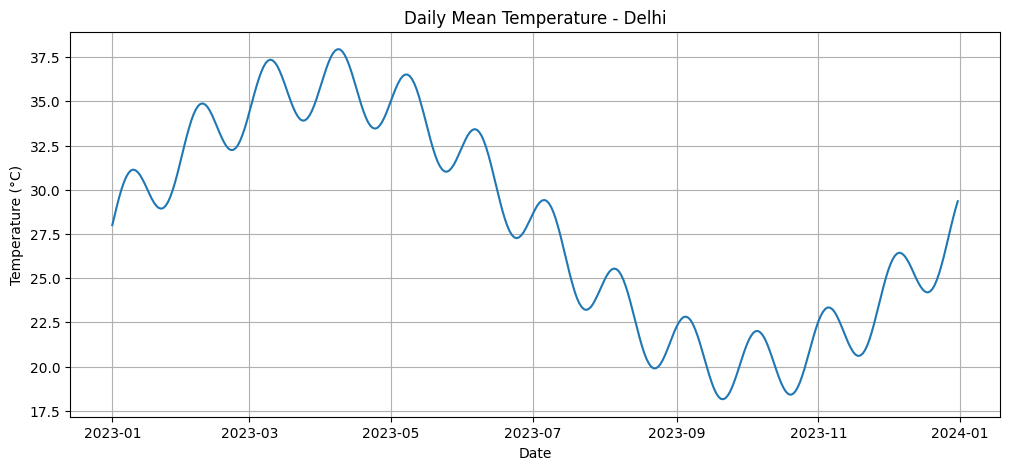

In [105]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/sample_data/DailyDelhiClimateTrain.csv")

# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Set date as index
df.set_index("date", inplace=True)

# Select mean temperature
temperature = df["meantemp"]

# Plot
plt.figure(figsize=(12,5))
plt.plot(temperature)
plt.title("Daily Mean Temperature - Delhi")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

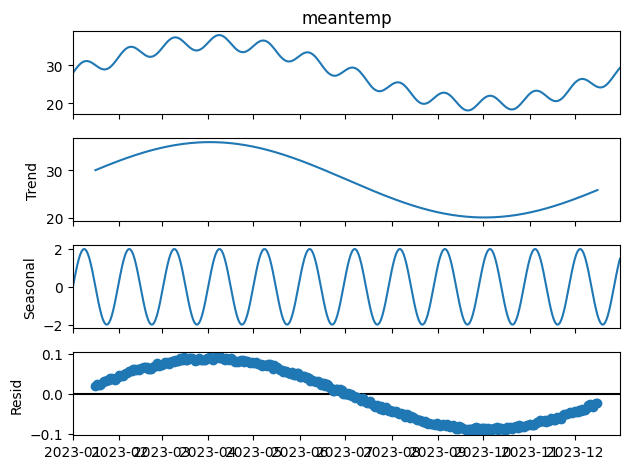

In [109]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the series
decomposition = seasonal_decompose(
    temperature,
    model="additive",
    period=30      # Works well for the sample dataset
)

# Plot decomposition
decomposition.plot()
plt.show()

In [110]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(temperature)

print("ADF Statistic :", result[0])
print("p-value :", result[1])

if result[1] < 0.05:
    print("The series is stationary.")
else:
    print("The series is NOT stationary.")

ADF Statistic : -14.152592682392706
p-value : 2.1488994810371587e-26
The series is stationary.


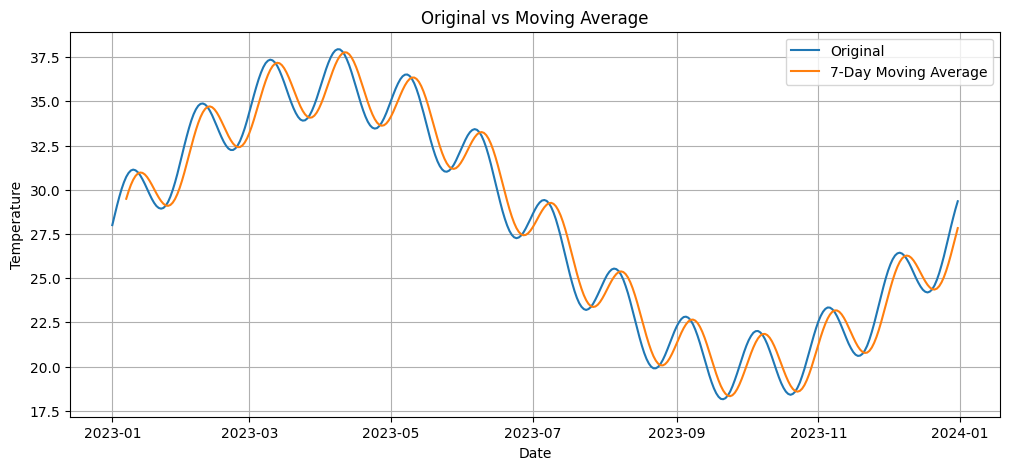

In [111]:
moving_average = temperature.rolling(window=7).mean()

plt.figure(figsize=(12,5))

plt.plot(temperature, label="Original")
plt.plot(moving_average, label="7-Day Moving Average")

plt.title("Original vs Moving Average")
plt.xlabel("Date")
plt.ylabel("Temperature")

plt.legend()
plt.grid(True)
plt.show()

In [112]:
from statsmodels.tsa.arima.model import ARIMA

# Build ARIMA model
model = ARIMA(temperature, order=(5,1,0))

# Train model
model_fit = model.fit()

# Forecast next 7 days
forecast = model_fit.forecast(steps=7)

print("Forecast for Next 7 Days")
print(forecast)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Forecast for Next 7 Days
2024-01-01    29.732695
2024-01-02    30.040770
2024-01-03    30.258743
2024-01-04    30.383377
2024-01-05    30.409788
2024-01-06    30.338598
2024-01-07    30.174912
Freq: D, Name: predicted_mean, dtype: float64


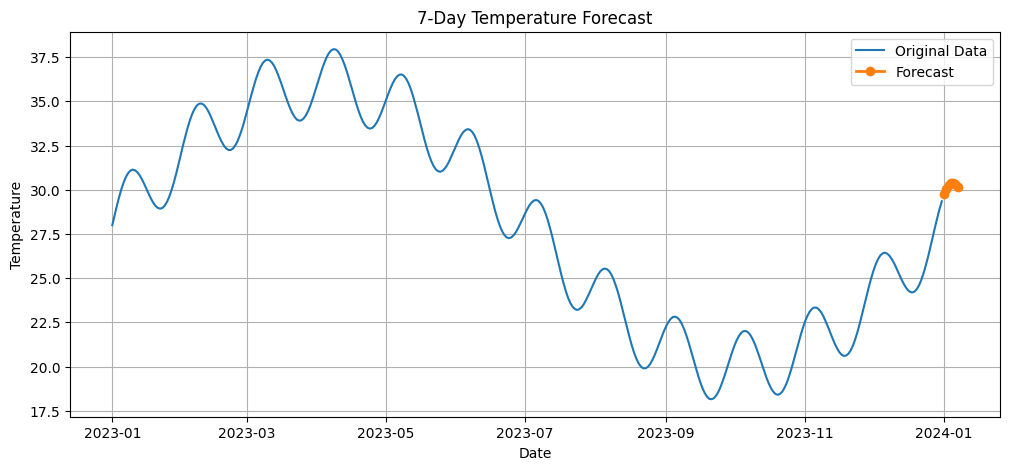

In [113]:
import pandas as pd
import matplotlib.pyplot as plt

# Create dates for forecast
future_dates = pd.date_range(
    start=temperature.index[-1] + pd.Timedelta(days=1),
    periods=7,
    freq="D"
)

plt.figure(figsize=(12,5))

plt.plot(temperature, label="Original Data")
plt.plot(future_dates, forecast,
         marker="o",
         linewidth=2,
         label="Forecast")

plt.title("7-Day Temperature Forecast")
plt.xlabel("Date")
plt.ylabel("Temperature")

plt.legend()
plt.grid(True)

plt.show()